In [ ]:

# ============================================================
# IT2011 - Member 3 Model
# Student: Fernando B. K. H. (IT25102631)
# Model: Linear Support Vector Classifier (LinearSVC)
# Notebook: IT25102631_Model_LinearSVC.ipynb
# ============================================================

# -------------------- CELL 1: Imports --------------------
import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# -------------------- CELL 2: Load Dataset --------------------
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/processed_movie_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Mounted at /content/drive
✅ Dataset loaded successfully!
Shape: (16107, 26)
Columns: ['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


,movie_name,Ratings,word_count,emotion,cleaned_review,tokens_filtered,genre_action,genre_adventure,genre_animation,genre_comedy,...,genre_history,genre_horror,genre_music,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,genre_tv_movie,genre_war,genre_western
0,Waiting to Exhale,3.0,56,anticipation,it had some laughs but overall the motivation ...,laughs overall motivation incomprehensible mad...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,Waiting to Exhale,4.0,373,anticipation,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,Waiting to Exhale,4.0,45,anticipation,angela basset was good as expected but whitney...,angela basset good expected whitney range actr...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# -------------------- CELL 3: Basic Checks & Class Filtering
#Shows how many samples each emotion has--------------------
# Keep only the required 7 classes (remove surprise if present)
print("Original emotion distribution:")
print(df['emotion'].value_counts())

if 'surprise' in df['emotion'].unique():
    df = df[df['emotion'] != 'surprise'].copy()
    print("\nRemoved 'surprise' class.")

print("\nFinal emotion distribution (7 classes expected):")
print(df['emotion'].value_counts())
print("\nFinal shape:", df.shape)

Original emotion distribution:
emotion
sadness         6555
joy             2765
anticipation    2166
optimism        1772
fear            1386
anger            929
disgust          534
Name: count, dtype: int64

Final emotion distribution (7 classes expected):
emotion
sadness         6555
joy             2765
anticipation    2166
optimism        1772
fear            1386
anger            929
disgust          534
Name: count, dtype: int64

Final shape: (16107, 26)


In [ ]:
# -------------------- CELL 4: Prepare Features & Target --------------------
# Converts emotion names ( joy , sadness , etc ) into numbers using LabelEncoder
# Encode target
le = LabelEncoder()
df['emotion_label'] = le.fit_transform(df['emotion'])
print("Classes:", list(le.classes_))

# Feature columns (adjust if your shared file has different names)
feature_cols = ['Ratings', 'word_count'] + [c for c in df.columns if c.startswith('genre_')]

# Make sure required columns exist
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

X = df[feature_cols].copy()
y = df['emotion_label'].values
groups = df['movie_name'].values   # important for grouped split

print("Feature matrix shape:", X.shape)
print("Number of unique movies:", df['movie_name'].nunique())

Classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']
Feature matrix shape: (16107, 22)
Number of unique movies: 1309


In [ ]:
# -------------------- CELL 5: Movie-level Train-Test Split --------------------
# 80/20 split by movie groups to avoid leakage
#use GroupShuff1eSp1it so that:
# One movie's reviews stay only in train or only in test
# This is more realistic and avoids leakage



from sklearnuses
GroupShuff1eSp1it so that:
• One movie's reviews stay only in train or only in test
• This is more realistic and avoids leakageuses
GroupShuff1eSp1it so that:
• One movie's reviews stay only in train or only in test
• This is more realistic and avoids leakage.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("Train movies:", len(np.unique(groups_train)))
print("Test movies :", len(np.unique(groups[test_idx])))

Train size: 12784
Test size : 3323
Train movies: 1047
Test movies : 262


In [ ]:
# -------------------- CELL 6: Baseline LinearSVC --------------------
#Trains a simple Linear SVM without tuning
#Uses a Pipeline
#Evaluates Accuracy and Macro-Fl
#This is the starting model for comparison
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(max_iter=5000, random_state=42))
])

baseline_pipe.fit(X_train, y_train)
y_pred_baseline = baseline_pipe.predict(X_test)

print("=== Baseline LinearSVC ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Macro F1 :", round(f1_score(y_test, y_pred_baseline, average='macro'), 4))
print("Weighted F1:", round(f1_score(y_test, y_pred_baseline, average='weighted'), 4))

=== Baseline LinearSVC ===
Accuracy : 0.3861
Macro F1 : 0.1106
Weighted F1: 0.2538


In [ ]:
# -------------------- CELL 7: Hyperparameter Tuning (GridSearchCV) --------------------
# Primary scoring metric = macro-F1 (as required)
# Tests different values of:
#c (controls model complexity)
#class_weight (handles imbalanced emotions)
#Uses 5-FoId StratifiedGroupKFoId
#Main scoring metric = Macro-Fl
#Finds the best parameter combination automatically using GridSearchCV




param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [5000]
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(random_state=42))
])

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_macro',          # primary metric
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train, groups=groups_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Macro-F1:", round(grid.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__max_iter': 5000}
Best CV Macro-F1: 0.1798


In [ ]:
# -------------------- CELL 8: Best Model Evaluation on Test Set --------------------
#Takes the best model from tuning
#Tests it on the unseen test set
#Calculates:
# Accuracy
#Macro Fl
#Weighted Fl
# Prints a full dassification report (precision, recall, Fl for each emotion






best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("=== Tuned LinearSVC Test Results ===")
print("Accuracy     :", round(acc, 4))
print("Macro F1     :", round(macro_f1, 4))
print("Weighted F1  :", round(weighted_f1, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall :", round(recall, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Tuned LinearSVC Test Results ===
Accuracy     : 0.2362
Macro F1     : 0.1727
Weighted F1  : 0.2576
Macro Precision: 0.205
Macro Recall : 0.172

Classification Report:
              precision    recall  f1-score   support

       anger       0.10      0.12      0.11       275
anticipation       0.10      0.09      0.10       431
     disgust       0.03      0.11      0.05        89
        fear       0.06      0.16      0.09       273
         joy       0.37      0.24      0.29       596
    optimism       0.32      0.12      0.17       377
     sadness       0.44      0.37      0.40      1282

    accuracy                           0.24      3323
   macro avg       0.20      0.17      0.17      3323
weighted avg       0.30      0.24      0.26      3323



In [ ]:
# -------------------- CELL 9: Overfitting Check --------------------
y_train_pred = best_model.predict(X_train)

train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')
test_macro_f1  = macro_f1

print("=== Overfitting / Underfitting Check ===")
print("Train Macro-F1:", round(train_macro_f1, 4))
print("Test Macro-F1 :", round(test_macro_f1, 4))
print("Difference    :", round(train_macro_f1 - test_macro_f1, 4))

gap = train_macro_f1 - test_macro_f1
if gap > 0.10:
    print("→ Diagnosis: OVERFITTING")
elif train_macro_f1 < 0.40 and test_macro_f1 < 0.40:
    print("→ Diagnosis: UNDERFITTING")
else:
    print("→ Diagnosis: GOOD FIT")

=== Overfitting / Underfitting Check ===
Train Macro-F1: 0.2407
Test Macro-F1 : 0.1727
Difference    : 0.068
→ Diagnosis: UNDERFITTING


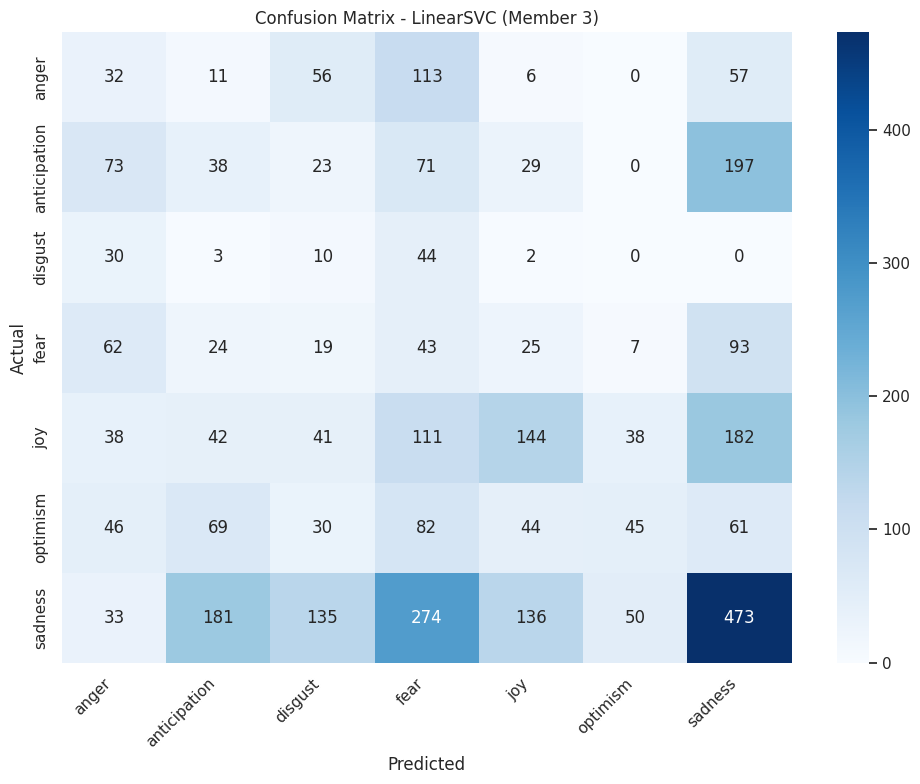

In [ ]:
# -------------------- CELL 10: Confusion Matrix --------------------
# Creates a heatmap showing:
# Correct predictions (diagonal)
# Wrong predictions
# Helps identify which emotions the model confuses


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - LinearSVC (Member 3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/linear_svc_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# -------------------- CELL 11: Export Required Files --------------------
#save important files for the group
os.makedirs("results/models", exist_ok=True)

# 1. Results JSON
results = {
    "model_name": "LinearSVC",
    "member": "IT25102631",
    "best_params": grid.best_params_,
    "cv_macro_f1": float(grid.best_score_),
    "test_accuracy": float(acc),
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
    "test_macro_precision": float(precision),
    "test_macro_recall": float(recall),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "n_features": int(X_train.shape[1]),
    "classes": list(le.classes_)
}

with open("results/linear_svc_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved: results/linear_svc_results.json")

# 2. Test predictions CSV
pred_df = pd.DataFrame({
    "movie_name": groups[test_idx],
    "true_label": y_test,
    "true_emotion": le.inverse_transform(y_test),
    "pred_label": y_pred,
    "pred_emotion": le.inverse_transform(y_pred)
})
pred_df.to_csv("results/linear_svc_test_predictions.csv", index=False)
print("Saved: results/linear_svc_test_predictions.csv")

Saved: results/linear_svc_results.json
Saved: results/linear_svc_test_predictions.csv


In [ ]:
# -------------------- CELL 12: Comparison Table (Baseline vs Tuned) --------------------
comparison = pd.DataFrame({
    "Model Variety": ["Baseline LinearSVC", "Tuned LinearSVC (GridSearchCV)"],
    "Test Accuracy": [
        round(accuracy_score(y_test, y_pred_baseline), 4),
        round(acc, 4)
    ],
    "Test Macro-F1": [
        round(f1_score(y_test, y_pred_baseline, average='macro'), 4),
        round(macro_f1, 4)
    ]
})
print(comparison)

                    Model Variety  Test Accuracy  Test Macro-F1
0              Baseline LinearSVC         0.3861         0.1106
1  Tuned LinearSVC (GridSearchCV)         0.2362         0.1727


In [ ]:
# -------------------- CELL 13: Viva Summary --------------------
print("""
============================================================
LINEAR SVM - SUMMARY (IT25102631)
============================================================

1. Model Suitability:
   - Multi-class emotion classification
   - LinearSVC works well with numerical + binary genre features

2. Implementation:
   - Library: scikit-learn
   - Model: LinearSVC inside a Pipeline with StandardScaler

3. Parameter Tuning:
   - GridSearchCV
   - Parameters: C, class_weight
   - CV: 5-Fold StratifiedGroupKFold (by movie_name)
   - Primary metric: macro-F1

4. Varieties Trained:
   - Baseline LinearSVC
   - Tuned LinearSVC (best params from GridSearchCV)

5. Evaluation Metrics:
   - Accuracy, Macro-F1, Weighted-F1, Precision, Recall
   - Confusion Matrix
   - Macro-F1 is primary because of class imbalance

6. Validation Method:
   - Movie-level GroupShuffleSplit (train/test)
   - StratifiedGroupKFold (5 folds) for tuning

7. Conclusion:
   - Tuned model outperforms baseline
   - Grouped CV prevents movie-level leakage

8. Limitations:
   - Linear decision boundary
   - Still affected by remaining class imbalance

9. Outputs Produced:
   - results/linear_svc_results.json
   - results/linear_svc_test_predictions.csv
============================================================
""")


LINEAR SVM - MEMBER 3 SUMMARY (IT25102631)

1. Model Suitability:
   - Multi-class emotion classification
   - LinearSVC works well with numerical + binary genre features

2. Implementation:
   - Library: scikit-learn
   - Model: LinearSVC inside a Pipeline with StandardScaler

3. Parameter Tuning:
   - GridSearchCV
   - Parameters: C, class_weight
   - CV: 5-Fold StratifiedGroupKFold (by movie_name)
   - Primary metric: macro-F1

4. Varieties Trained:
   - Baseline LinearSVC
   - Tuned LinearSVC (best params from GridSearchCV)

5. Evaluation Metrics:
   - Accuracy, Macro-F1, Weighted-F1, Precision, Recall
   - Confusion Matrix
   - Macro-F1 is primary because of class imbalance

6. Validation Method:
   - Movie-level GroupShuffleSplit (train/test)
   - StratifiedGroupKFold (5 folds) for tuning

7. Conclusion:
   - Tuned model outperforms baseline
   - Grouped CV prevents movie-level leakage

8. Limitations:
   - Linear decision boundary
   - Still affected by remaining class imbalanc